# HVAC Electircity Demand Analysis and Prediction

## Feature Creation and lag features Tuning

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor,
    BaggingRegressor,
)

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)

In [74]:
df_daily = pd.read_csv("./data/df_daily_feature_lags.csv")
df_daily["Time"] = pd.to_datetime(df_daily["Time"])
df_daily.set_index("Time", inplace=True)

In [75]:
df_daily.describe().T


,count,mean,std,min,25%,50%,75%,max
electricity_demand_values,2920.0,9453.465406,3230.948896,5106.015997,6836.863624,8863.772704,11172.705523,25405.855701
air_pressure,2920.0,734.587334,3.206897,724.691667,732.450000,734.291667,736.489583,747.420833
solar_irridiation_positive,2920.0,475.002634,31.305920,371.615385,452.961538,475.230769,496.307692,582.538462
total_cloud_cover_percent,2920.0,0.323900,0.178468,0.000000,0.191120,0.302083,0.427083,0.979167
heat_demand_change,2920.0,242.948577,195.794822,0.000000,63.383740,226.243712,382.887329,820.829240
...,...,...,...,...,...,...,...,...
electricity_demand_lag_4,2916.0,9450.687400,3232.231452,5106.015997,6835.320613,8860.000315,11167.701133,25405.855701
electricity_demand_lag_5,2915.0,9450.094755,3232.627545,5106.015997,6835.059110,8858.612548,11163.190814,25405.855701
electricity_demand_lag_6,2914.0,9449.146808,3232.777110,5106.015997,6834.797607,8856.317104,11157.115812,25405.855701
electricity_demand_lag_7,2913.0,9447.984793,3232.723413,5106.015997,6834.536104,8854.021659,11148.470779,25405.855701


## Sliding window method for electricity demand and heating demand

### Add lag features for electricity demand and heating demand (sliding window method)

- Average electricity demand in the past few days
- Average heating demand standard deviation in the past few days
- Electricity demand per day in the past few days

In [76]:
df_daily.columns

Index(['electricity_demand_values', 'air_pressure',
       'solar_irridiation_positive', 'total_cloud_cover_percent',
       'heat_demand_change', 'air_temperature_range', 'air_temperature_high',
       'air_temperature_low', 'wind_speed_range', 'Wind scale 2',
       'Wind scale 3', 'huimidity_Comfort', 'huimidity_Uncomfortable Dry',
       'huimidity_Uncomfortable Wet', 'temp_0_10', 'temp_10_20', 'temp_20_30',
       'temp_30_40', 'temp_nega_10_0', 'Is_Weekday_0', 'Is_Weekday_1',
       'Is_Weekday_2', 'Is_Weekday_3', 'Is_Weekday_4', 'Is_Weekday_5',
       'Is_Weekday_6', 'Quarter_1', 'Quarter_2', 'Quarter_3', 'Quarter_4',
       'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
       'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
       'electricity_demand_2d_mean', 'electricity_demand_2d_std',
       'heat_demand_2d_mean', 'heat_demand_2d_std',
       'electricity_demand_3d_mean', 'electricity_demand_3d_std',
       'heat_demand_3d_mean', 'hea

In [77]:
# df_daily = df_daily.drop(
#     columns=[
#         # "Quarter_1",
#         # "Quarter_2",
#         # "Quarter_3",
#         # "Quarter_4",
#         # "air_temperature_range",
#         # "wind_speed_range",
#         # "heat_demand_change",
#     ],
#     axis=1,
# )

## Training and Testing models

In [78]:
def train_test_set(df, start, end, split_time):
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test

In [79]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 78), (516,), (172, 78), (172,))

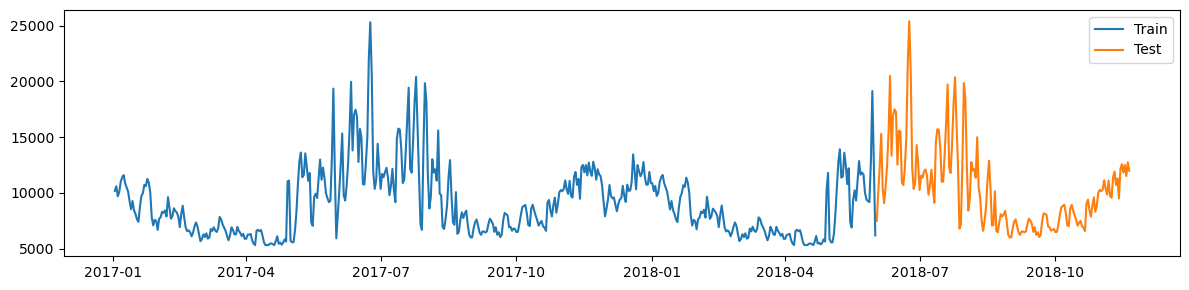

In [80]:
_, ax = plt.subplots(figsize=(12, 3))

ax.plot(y_train.index, y_train, label="Train")
ax.plot(y_test.index, y_test, label="Test")

plt.legend()
plt.tight_layout()

plt.show()


In [81]:
def train_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_pred - y_test))
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    df_results = pd.DataFrame(
        {"Time": y_test.index, "y_test": y_test, "y_pred": y_pred}
    )
    return df_results

In [82]:
def plot_results(df_results, model_name):
    _, ax = plt.subplots(figsize=(12, 3))
    ax.plot(df_results["Time"], df_results["y_test"], label="Test")
    ax.plot(df_results["Time"], df_results["y_pred"], label="Predicted")
    ax.set_title(model_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [83]:
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
df_results = train_model(X_train, y_train, X_test, y_test, dt_reg)

RMSE: 2022.9858
MAE: 1202.7124
R2: 0.6982


In [84]:
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

df_results = train_model(X_train, y_train, X_test, y_test, RF_reg)

RMSE: 1396.2609
MAE: 899.4944
R2: 0.8562


In [85]:
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

df_results = train_model(X_train, y_train, X_test, y_test, ada_reg)

RMSE: 1207.4350
MAE: 727.7634
R2: 0.8925


In [86]:
ada_reg = AdaBoostRegressor(
    RF_reg,
    n_estimators=100,
    random_state=42,
)

df_results = train_model(X_train, y_train, X_test, y_test, ada_reg)

RMSE: 1229.8575
MAE: 846.4493
R2: 0.8885


### Feature Selection PCA

In [87]:
pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

In [88]:
k_explain = []

k = 0
for i in range(len(pca.explained_variance_ratio_)):
    k = k + pca.explained_variance_ratio_[i]
    k_explain.append(k)

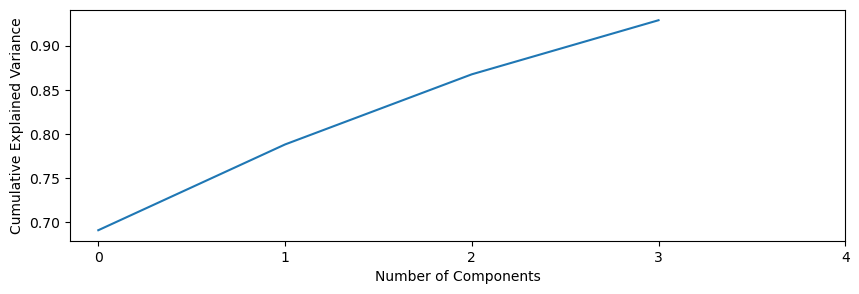

In [89]:
_, ax = plt.subplots(figsize=(10, 3))


ax.plot(np.cumsum(pca.explained_variance_ratio_))
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.xaxis.set_ticks(np.arange(0, 5, 1))
plt.show()

In [90]:
ada_reg = AdaBoostRegressor(
    RF_reg,
    n_estimators=100,
    random_state=42,
)

df_results = train_model(X_train_pca, y_train, X_test_pca, y_test, ada_reg)


RMSE: 1044.3311
MAE: 763.3867
R2: 0.9196


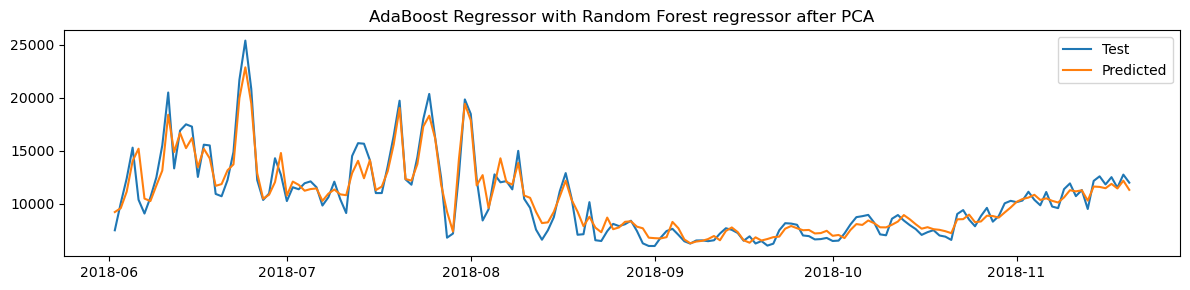

In [91]:
plot_results(df_results, "AdaBoost Regressor with Random Forest regressor after PCA")

In [9]:
def train_model_tuning(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_pred - y_test))
    r2 = r2_score(y_test, y_pred)
    return rmse, mae, r2, y_pred


In [10]:
# models = {
#     "LinearRegression": LinearRegression(),
#     "Ridge": Ridge(),
#     "Lasso": Lasso(),
#     "DecisionTreeRegressor": DecisionTreeRegressor(),
#     "AdaBoostRegressor": AdaBoostRegressor(
#         RandomForestRegressor(
#             n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
#         ),
#         n_estimators=100,
#     ),
#     "RandomForestRegressor": RandomForestRegressor(),
#     "GradientBoostingRegressor": GradientBoostingRegressor(),
#     "BaggingRegressor": BaggingRegressor(),
# }


# results_df_tuning = pd.DataFrame()


# for name, model in models.items():
#     print(f"Training model: {name}")
#     rmse, mae, r2, y_pred = train_model_tuning(X_train, y_train, X_test, y_test, model)
#     df_tuning = pd.DataFrame(
#         {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2},
#     )
#     results_df_tuning = pd.concat([results_df_tuning, df_tuning], axis=0)

Training model: LinearRegression
Training model: Ridge
Training model: Lasso
Training model: DecisionTreeRegressor
Training model: AdaBoostRegressor


/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.297e+08, tolerance: 4.811e+05
  model = cd_fast.enet_coordinate_descent(


Training model: RandomForestRegressor
Training model: GradientBoostingRegressor
Training model: BaggingRegressor


In [11]:
# results_df_tuning

,Model,RMSE,MAE,R2
0,LinearRegression,1785.103946,1222.826769,0.765019
0,Ridge,1760.958582,1202.770453,0.771333
0,Lasso,1760.792763,1163.703081,0.771376
0,DecisionTreeRegressor,1838.171528,1001.586092,0.750841
0,AdaBoostRegressor,1207.353880,821.631738,0.892508
0,RandomForestRegressor,1353.509531,874.624066,0.864909
0,GradientBoostingRegressor,1182.760721,816.222098,0.896843
0,BaggingRegressor,1510.774835,931.805252,0.831692


| Model | RMSE                      | MAE         | R2          |          |
| ----- | ------------------------- | ----------- | ----------- | -------- |
| 0     | LinearRegression          | 1785.103946 | 1222.826769 | 0.765019 |
| 0     | Ridge                     | 1760.958582 | 1202.770453 | 0.771333 |
| 0     | Lasso                     | 1760.792763 | 1163.703081 | 0.771376 |
| 0     | DecisionTreeRegressor     | 1838.171528 | 1001.586092 | 0.750841 |
| 0     | AdaBoostRegressor         | 1207.353880 | 821.631738  | 0.892508 |
| 0     | RandomForestRegressor     | 1353.509531 | 874.624066  | 0.864909 |
| 0     | GradientBoostingRegressor | 1182.760721 | 816.222098  | 0.896843 |
| 0     | BaggingRegressor          | 1510.774835 | 931.805252  | 0.831692 |

In [12]:
# Define a dictionary of models and their corresponding hyperparameter grids
models = {
    "RandomForestRegressor": {
        "model": RandomForestRegressor(),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "max_depth": [5, 10, 20],
            "min_samples_split": [2, 5, 10],
        },
    },
    "GradientBoostingRegressor": {
        "model": GradientBoostingRegressor(),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 4, 5],
        },
    },
    "BaggingRegressor": {
        "model": BaggingRegressor(),
        "param_grid": {
            "n_estimators": [50, 100, 200],
        },
    },
    "AdaBoostRegressor with GradientBoostingRegressor": {
        "model": AdaBoostRegressor(
            GradientBoostingRegressor(random_state=42),
        ),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 1.0],
        },
    },
    "AdaBoostRegressor with RandomForestRegressor": {
        "model": AdaBoostRegressor(
            RandomForestRegressor(random_state=42),
        ),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 1.0],
        },
    },
    "AdaBoostRegressor with DecisionTreeRegressor": {
        "model": AdaBoostRegressor(
            DecisionTreeRegressor(random_state=42),
        ),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 1.0],
        },
    },
}

In [13]:
results_df_tuning = pd.DataFrame()

for name, model_info in models.items():
    model = model_info["model"]
    param_grid = model_info["param_grid"]

    print(f"Training model: {name}")

    # Create the model with GridSearchCV
    grid_search = GridSearchCV(
        model, param_grid, cv=5, scoring="neg_mean_squared_error"
    )

    # Fit the model to your training data
    grid_search.fit(X_train, y_train)

    # Get the best hyperparameters and the best model
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    # Use the best model for prediction
    y_pred = best_model.predict(X_test)

    # Evaluate the model's performance
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Create a DataFrame with the results
    df_tuning = pd.DataFrame(
        {
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Best Hyperparameters": [best_params],
        }
    )

    results_df_tuning = pd.concat([results_df_tuning, df_tuning], axis=0)

Training model: RandomForestRegressor
Training model: GradientBoostingRegressor
Training model: BaggingRegressor
Training model: AdaBoostRegressor with GradientBoostingRegressor
Training model: AdaBoostRegressor with RandomForestRegressor
Training model: AdaBoostRegressor with DecisionTreeRegressor


In [14]:
results_df_tuning

,Model,RMSE,MAE,R2,Best Hyperparameters
0,RandomForestRegressor,1372.808246,871.875646,0.861029,"{'max_depth': 20, 'min_samples_split': 5, 'n_e..."
0,GradientBoostingRegressor,1099.113831,745.819733,0.910918,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
0,BaggingRegressor,1379.509844,888.371370,0.859669,{'n_estimators': 50}
0,AdaBoostRegressor with GradientBoostingRegressor,1256.737006,821.954850,0.883535,"{'learning_rate': 0.01, 'n_estimators': 50}"
0,AdaBoostRegressor with RandomForestRegressor,1337.279705,869.938999,0.868129,"{'learning_rate': 0.01, 'n_estimators': 100}"
0,AdaBoostRegressor with DecisionTreeRegressor,1330.060269,741.349765,0.869549,"{'learning_rate': 0.01, 'n_estimators': 100}"


| Model | RMSE                                             | MAE         | R2         | Best Hyperparameters |                                                   |
| ----- | ------------------------------------------------ | ----------- | ---------- | -------------------- | ------------------------------------------------- |
| 0     | RandomForestRegressor                            | 1372.808246 | 871.875646 | 0.861029             | {'max_depth': 20, 'min_samples_split': 5, 'n_e... |
| 0     | GradientBoostingRegressor                        | 1099.113831 | 745.819733 | 0.910918             | {'learning_rate': 0.1, 'max_depth': 3, 'n_esti... |
| 0     | BaggingRegressor                                 | 1379.509844 | 888.371370 | 0.859669             | {'n_estimators': 50}                              |
| 0     | AdaBoostRegressor with GradientBoostingRegressor | 1256.737006 | 821.954850 | 0.883535             | {'learning_rate': 0.01, 'n_estimators': 50}       |
| 0     | AdaBoostRegressor with RandomForestRegressor     | 1337.279705 | 869.938999 | 0.868129             | {'learning_rate': 0.01, 'n_estimators': 100}      |
| 0     | AdaBoostRegressor with DecisionTreeRegressor     | 1330.060269 | 741.349765 | 0.869549             | {'learning_rate': 0.01, 'n_estimators': 100}      |

models = {
    "RandomForestRegressor": {
        "model": RandomForestRegressor(),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "max_depth": [5, 10, 20],
            "min_samples_split": [2, 5, 10],
        },
    },
    "GradientBoostingRegressor": {
        "model": GradientBoostingRegressor(),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 4, 5],
        },
    },
    "BaggingRegressor": {
        "model": BaggingRegressor(),
        "param_grid": {
            "n_estimators": [50, 100, 200],
        },
    },
    "AdaBoostRegressor with GradientBoostingRegressor": {
        "model": AdaBoostRegressor(
            GradientBoostingRegressor(random_state=42),
        ),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 1.0],
        },
    },
    "AdaBoostRegressor with RandomForestRegressor": {
        "model": AdaBoostRegressor(
            RandomForestRegressor(random_state=42),
        ),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 1.0],
        },
    },
    "AdaBoostRegressor with DecisionTreeRegressor": {
        "model": AdaBoostRegressor(
            DecisionTreeRegressor(random_state=42),
        ),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 1.0],
        },
    },
}